<a href="https://colab.research.google.com/github/Josetob246/Veramo-IA/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mariana Camacho Castro 2121763 Jose Luis Tobias Hinojosa 1992178


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
251/251 - 98s - 390ms/step - accuracy: 0.6349 - loss: 1.2826 - val_accuracy: 0.4823 - val_loss: 1.5321
Epoch 2/30
251/251 - 92s - 367ms/step - accuracy: 0.6697 - loss: 0.9619 - val_accuracy: 0.5172 - val_loss: 1.4299
Epoch 3/30
251/251 - 98s - 389ms/step - accuracy: 0.6870 - loss: 0.8963 - val_accuracy: 0.6940 - val_loss: 0.8964
Epoch 4/30
251/251 - 92s - 367ms/step - accuracy: 0.6858 - loss: 0.8907 - val_accuracy: 0.6740 - val_loss: 1.1722
Epoch 5/30
251/251 - 94s - 373ms/step - accuracy: 0.6958 - loss: 0.8479 - val_accuracy: 0.7084 - val_loss: 0.9164
Epoch 6/30
251/251 - 92s - 368ms/step - accuracy: 0.7032 - loss: 0.8180 - val_accuracy: 0.6800 - val_loss: 0.9269
Epoch 7/30
251/251 - 91s - 361ms/step - accuracy: 0.7039 - loss: 0.8137 - val_accuracy: 0.7129 - val_loss: 0.9283
Epoch 8/30
251/251 - 92s - 366ms/step - accuracy: 0.7067 - loss: 0.8053 - val_accuracy: 0.6805 - val_loss: 1.0852
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


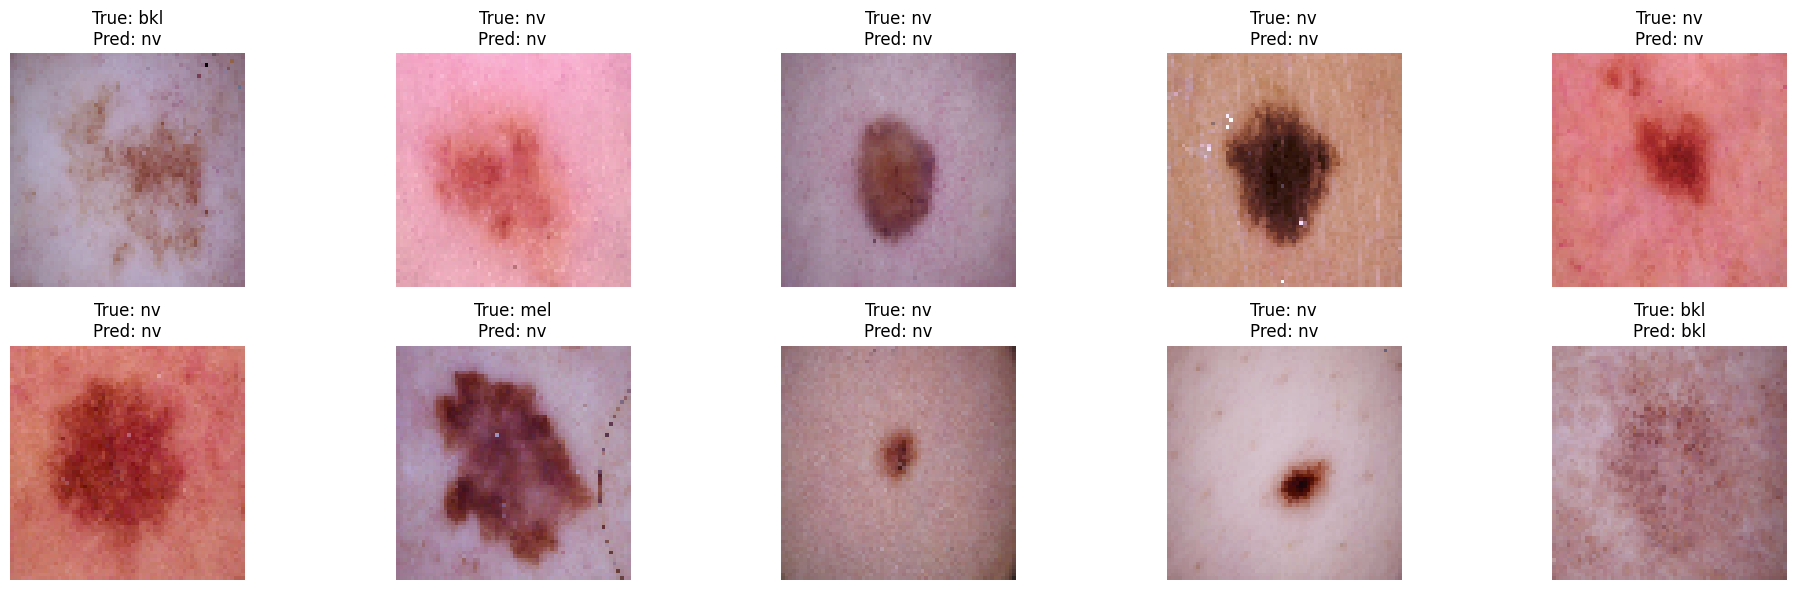

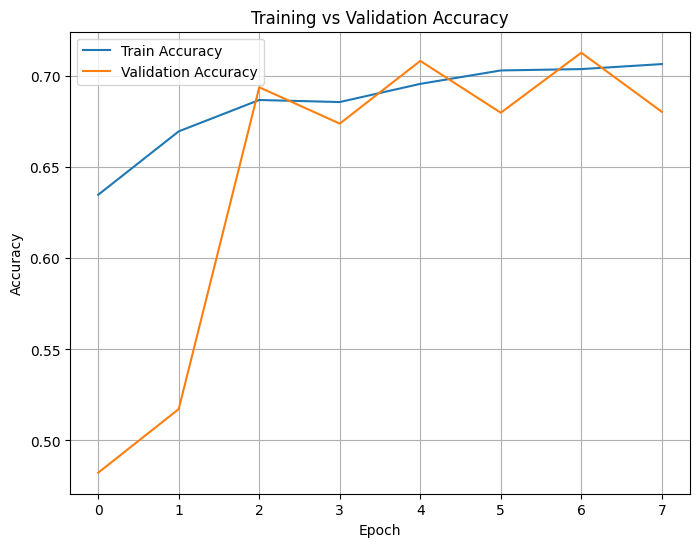

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array, to_categorical
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from google.colab import drive

IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42

# Load data from Drive
drive.mount('/content/drive')


csv_path = '/content/drive/MyDrive/HAM10000_metadata.csv'
df = pd.read_csv(csv_path)

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['dx'])
num_classes = len(le.classes_)


DATA_DIRS = ['/content/drive/MyDrive/HAM1000/HAM10000_images_part_1', '/content/drive/MyDrive/HAM1000/HAM10000_images_part_2']
#Preprocessing
def load_and_preprocess_image(image_id):
    for data_dir in DATA_DIRS:
        img_path = os.path.join(data_dir, image_id + ".jpg")
        if os.path.exists(img_path):
            img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
            img = img_to_array(img) / 255.0
            return img
    raise FileNotFoundError(f"Image {image_id}.jpg not found in any data directory.")

images = np.array([load_and_preprocess_image(img_id) for img_id in df['image_id']])
labels = to_categorical(df['label_enc'], num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=SEED, stratify=labels)

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)
datagen.fit(X_train)

#Model Selection
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=2
)

pred_indices = np.random.choice(len(X_test), 10, replace=False)
X_sample = X_test[pred_indices]
y_sample_true = y_test[pred_indices]
y_sample_pred = model.predict(X_sample)
y_sample_pred_labels = le.inverse_transform(np.argmax(y_sample_pred, axis=1))
y_sample_true_labels = le.inverse_transform(np.argmax(y_sample_true, axis=1))

plt.figure(figsize=(20, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_sample[i])
    plt.title(f"True: {y_sample_true_labels[i]}\nPred: {y_sample_pred_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
